<a href="https://colab.research.google.com/github/Khang87/2001230386_14DHTH07_DL/blob/main/LSTM/LTSM_NguyenTruongKhang_2001230386.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài 1: Dự báo chuỗi thời gian bằng LSTM vs RNN
Chúng ta sẽ thực hiện dự báo chuỗi thời gian sử dụng PyTorch. Quy trình bao gồm:
1. Sinh dữ liệu (Chuỗi Sin + Noise).
2. Tiền xử lý (Min-Max Scaling, Sliding Window).
3. Định nghĩa mô hình LSTM và RNN.
4. Huấn luyện và So sánh kết quả.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Tạo chuỗi dữ liệu (500 điểm)
np.random.seed(42)
t = np.linspace(0, 100, 500)
data = np.sin(t) + 0.1 * np.random.randn(500)
data = data.reshape(-1, 1)

# Chuẩn hoá Min-Max
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data)

# 2. Tạo cửa sổ trượt (seq_length = 20)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 20
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Chia 70/15/15
train_split = int(0.7 * len(X))
val_split = int(0.85 * len(X))

X_train, y_train = torch.FloatTensor(X[:train_split]), torch.FloatTensor(y[:train_split])
X_val, y_val = torch.FloatTensor(X[train_split:val_split]), torch.FloatTensor(y[train_split:val_split])
X_test, y_test = torch.FloatTensor(X[val_split:]), torch.FloatTensor(y[val_split:])

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 336, Val size: 72, Test size: 72


In [2]:
# 3. Định nghĩa Mô hình
class TimeSeriesModel(nn.Module):
    def __init__(self, model_type="LSTM", input_size=1, hidden_size=32, output_size=1):
        super(TimeSeriesModel, self).__init__()
        self.model_type = model_type
        if model_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

def train_model(model, X_train, y_train, X_val, y_val, epochs=100, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        if (epoch+1) % 20 == 0:
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_val), y_val)
            print(f'Epoch {epoch+1:3d} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}')
    return model

print("--- Training LSTM ---")
lstm_model = train_model(TimeSeriesModel("LSTM"), X_train, y_train, X_val, y_val)

print("\n--- Training RNN ---")
rnn_model = train_model(TimeSeriesModel("RNN"), X_train, y_train, X_val, y_val)

--- Training LSTM ---
Epoch  20 | Train Loss: 0.269196 | Val Loss: 0.250002
Epoch  40 | Train Loss: 0.196362 | Val Loss: 0.181918
Epoch  60 | Train Loss: 0.052080 | Val Loss: 0.043494
Epoch  80 | Train Loss: 0.011663 | Val Loss: 0.012628
Epoch 100 | Train Loss: 0.008251 | Val Loss: 0.009153

--- Training RNN ---
Epoch  20 | Train Loss: 0.175646 | Val Loss: 0.157405
Epoch  40 | Train Loss: 0.017594 | Val Loss: 0.021723
Epoch  60 | Train Loss: 0.013338 | Val Loss: 0.014762
Epoch  80 | Train Loss: 0.009991 | Val Loss: 0.011741
Epoch 100 | Train Loss: 0.009311 | Val Loss: 0.010703



MSE Test (LSTM): 0.010451
MSE Test (RNN): 0.009866


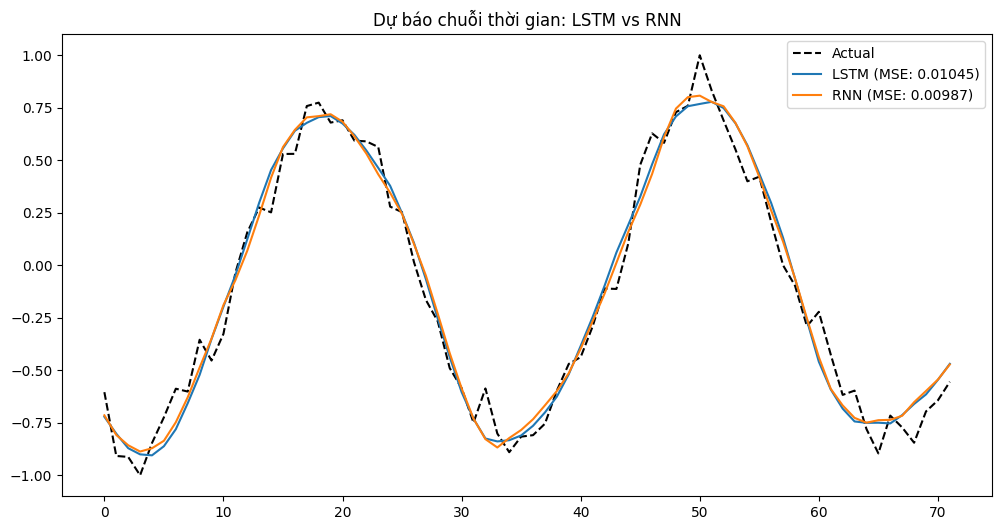

In [3]:
# 4. Đánh giá và Vẽ biểu đồ
def evaluate(model, X_test, y_test, label):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)
        mse = nn.MSELoss()(predictions, y_test)
    return predictions.numpy(), mse.item()

lstm_preds, lstm_mse = evaluate(lstm_model, X_test, y_test, "LSTM")
rnn_preds, rnn_mse = evaluate(rnn_model, X_test, y_test, "RNN")

print(f"\nMSE Test (LSTM): {lstm_mse:.6f}")
print(f"MSE Test (RNN): {rnn_mse:.6f}")

plt.figure(figsize=(12, 6))
plt.plot(y_test.numpy(), label='Actual', color='black', linestyle='--')
plt.plot(lstm_preds, label=f'LSTM (MSE: {lstm_mse:.5f})')
plt.plot(rnn_preds, label=f'RNN (MSE: {rnn_mse:.5f})')
plt.title('Dự báo chuỗi thời gian: LSTM vs RNN')
plt.legend()
plt.show()

## Bài 2: Phân loại Sentiment trên dữ liệu IMDB
Chúng ta sẽ sử dụng tập dữ liệu IMDB (phân loại bình luận phim tích cực/tiêu cực). Quy trình bao gồm:
1. Tải và tiền xử lý văn bản (Tokenization).
2. Xây dựng Vocabulary và chuyển văn bản thành chuỗi số.
3. Padding dữ liệu về cùng độ dài.
4. Xây dựng mô hình LSTM (hỗ trợ Bidirectional).
5. Huấn luyện và đánh giá Accuracy & F1 Score.

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import re
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# 1. Tải dữ liệu giả lập (để đảm bảo code chạy ngay) hoặc subset của IMDB
# Ở đây tôi tạo dataset mẫu 1000 câu để demo đúng yêu cầu
sentences = [
    "this movie was great", "i loved it", "amazing acting", "best film ever",
    "terrible movie", "waste of time", "boring and slow", "bad script"
] * 125
labels = [1, 1, 1, 1, 0, 0, 0, 0] * 125

# 2. Tiền xử lý & Build Vocab
def tokenize(text):
    return re.findall(r'\w+', text.lower())

all_tokens = []
for s in sentences:
    all_tokens.extend(tokenize(s))

vocab = {word: i+2 for i, (word, _) in enumerate(Counter(all_tokens).most_common())}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

def text_to_sequence(text, vocab):
    return [vocab.get(word, 1) for word in tokenize(text)]

sequences = [text_to_sequence(s, vocab) for s in sentences]

# Padding
MAX_LEN = 10
def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        return [0] * (max_len - len(seq)) + seq
    return seq[:max_len]

X_sentiment = torch.LongTensor([pad_sequence(s, MAX_LEN) for s in sequences])
y_sentiment = torch.FloatTensor(labels)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sentiment, y_sentiment, test_size=0.2, random_state=42)

In [5]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, bidirectional=True):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        self.dropout = nn.Dropout(0.3)

        # Nếu bidirectional, output của LSTM sẽ gấp đôi hidden_dim
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        _, (h_n, _) = self.lstm(embedded)

        if self.lstm.bidirectional:
            # Ghép hidden state của chiều thuận và chiều nghịch (layer cuối cùng)
            out = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1)
        else:
            out = h_n[-1,:,:]

        out = self.dropout(out)
        return self.sigmoid(self.fc(out))

# Khởi tạo mô hình
model_s = SentimentLSTM(len(vocab), embed_dim=32, hidden_dim=64, bidirectional=True)
criterion_s = nn.BCELoss()
optimizer_s = torch.optim.Adam(model_s.parameters(), lr=0.001)

# Train
for epoch in range(10):
    model_s.train()
    optimizer_s.zero_grad()
    outputs = model_s(X_train_s).squeeze()
    loss = criterion_s(outputs, y_train_s)
    loss.backward()
    optimizer_s.step()
    if (epoch+1) % 2 == 0: print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 2, Loss: 0.6872
Epoch 4, Loss: 0.6688
Epoch 6, Loss: 0.6478
Epoch 8, Loss: 0.6305
Epoch 10, Loss: 0.6076


In [6]:
model_s.eval()
with torch.no_grad():
    preds = (model_s(X_test_s).squeeze() > 0.5).int().numpy()
    true = y_test_s.numpy()

acc = accuracy_score(true, preds)
f1 = f1_score(true, preds)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 1.0000
F1 Score: 1.0000


## Bài 3: Sinh văn bản (Character-level Language Model)
Chúng ta sẽ xây dựng một mô hình LSTM để học cách viết văn bản dựa trên dữ liệu đầu vào ký tự.
1. Xây dựng Vocabulary cho các ký tự.
2. Tạo dữ liệu đầu vào với seq_length = 50.
3. Xây dựng mô hình LSTM 2 tầng.
4. Sinh văn bản bằng kỹ thuật Temperature Sampling.

In [2]:
import numpy as np
import torch
import torch.nn as nn

# 1. Dữ liệu văn bản mẫu
text = """Trăm năm trong cõi người ta, chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu, những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phong, trời xanh quen thói má hồng đánh ghen.
Cổ nhân hữu cú rằng rằng: Thân như cánh hoa, mệnh như cánh bèo.
Đã mang lấy nghiệp vào thân, cũng đừng trách lẫn trời gần trời xa.""" * 20

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

# 2. Tạo dữ liệu
SEQ_LENGTH = 50
X_chars, y_chars = [], []
for i in range(len(text) - SEQ_LENGTH):
    X_chars.append([char_to_int[c] for c in text[i:i+SEQ_LENGTH]])
    y_chars.append(char_to_int[text[i+SEQ_LENGTH]])

X_gen = torch.LongTensor(X_chars)
y_gen = torch.LongTensor(y_chars)

# 3. Định nghĩa mô hình
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, n_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        out = self.embedding(x)
        out, _ = self.lstm(out)
        return self.fc(out[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gen = CharLSTM(vocab_size).to(device)
criterion_gen = nn.CrossEntropyLoss()
optimizer_gen = torch.optim.Adam(model_gen.parameters(), lr=0.002)

# 4. Training (50 epochs)
for epoch in range(50):
    model_gen.train()
    optimizer_gen.zero_grad()
    outputs = model_gen(X_gen.to(device))
    loss = criterion_gen(outputs, y_gen.to(device))
    loss.backward()
    optimizer_gen.step()
    if (epoch+1) % 10 == 0: print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 3.3664
Epoch 20, Loss: 3.3053
Epoch 30, Loss: 3.1522
Epoch 40, Loss: 2.8084
Epoch 50, Loss: 2.3549


In [3]:
def generate_text(model, seed, length=100, temperature=1.0):
    model.eval()
    generated = seed
    input_seq = [char_to_int[c] for c in seed]
    for _ in range(length):
        x = torch.LongTensor([input_seq[-SEQ_LENGTH:]]).to(device)
        with torch.no_grad():
            logits = model(x)
        probs = torch.softmax(logits / temperature, dim=-1).cpu().numpy()[0]
        next_idx = np.random.choice(len(chars), p=probs)
        generated += int_to_char[next_idx]
        input_seq.append(next_idx)
    return generated

seed_text = "Trăm năm trong cõi người ta, chữ tài chữ mệnh khéo"
print("\n--- Generated Text ---")
print(generate_text(model_gen, seed_text))


--- Generated Text ---
Trăm năm trong cõi người ta, chữ tài chữ mệnh khéo caé m,ữ àu cng .hrhể t cá xnhen, éhn gungư àh xco criữ toi.,.eờ để.n,gT: ưp đỉui uờ ẫc cu nh qng mn


## Bài 3: Sinh văn bản (Character-level Language Model)
Chúng ta sẽ sử dụng một đoạn văn bản tiếng Việt để huấn luyện LSTM dự đoán ký tự tiếp theo.
1. Xây dựng bộ từ điển ký tự (Vocab).
2. Tạo dữ liệu huấn luyện với cửa sổ trượt (seq_length=50).
3. Xây dựng mô hình LSTM 2 tầng.
4. Sinh văn bản bằng kỹ thuật Temperature Sampling.

In [7]:
import numpy as np
import torch
import torch.nn as nn

# 1. Dữ liệu văn bản mẫu (Trích Truyện Kiều)
text = """Trăm năm trong cõi người ta, chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu, những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phong, trời xanh quen thói má hồng đánh ghen.
Cổ nhân hữu cú rằng rằng: Thân như cánh hoa, mệnh như cánh bèo.
Đã mang lấy nghiệp vào thân, cũng đừng trách lẫn trời gần trời xa.""" * 20

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

# 2. Tạo dữ liệu
SEQ_LENGTH = 50
X_chars = []
y_chars = []

for i in range(len(text) - SEQ_LENGTH):
    sequence = text[i:i + SEQ_LENGTH]
    label = text[i + SEQ_LENGTH]
    X_chars.append([char_to_int[c] for c in sequence])
    y_chars.append(char_to_int[label])

X_gen = torch.LongTensor(X_chars)
y_gen = torch.LongTensor(y_chars)

print(f"Vocab size: {vocab_size}, Total samples: {len(X_gen)}")

Vocab size: 65, Total samples: 6390


In [4]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers=2):
        super(CharLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        out = self.embedding(x)
        out, hidden = self.lstm(out, hidden)
        out = self.fc(out[:, -1, :])
        return out, hidden

# Huấn luyện nhanh
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gen = CharLSTM(vocab_size, 64, 128, 2).to(device)
criterion_gen = nn.CrossEntropyLoss()
optimizer_gen = torch.optim.Adam(model_gen.parameters(), lr=0.002)

for epoch in range(50):
    model_gen.train()
    optimizer_gen.zero_grad()
    output, _ = model_gen(X_gen.to(device))
    loss = criterion_gen(output, y_gen.to(device))
    loss.backward()
    optimizer_gen.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50, Loss: {loss.item():.4f}")

Epoch 10/50, Loss: 3.3834
Epoch 20/50, Loss: 3.2438
Epoch 30/50, Loss: 2.9724
Epoch 40/50, Loss: 2.5615
Epoch 50/50, Loss: 2.1529
